In [1]:
# import libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

Cannot find header.dxf (GDAL_DATA is not defined)


In [2]:
# load datasets
sst_ds = xr.open_dataset('../data/sst.mon.mean_OISSTv2p1_IndoPacific_lon20E-290E_lat30S-30N_198109-202607.nc')
pr_ds = xr.open_dataset('../data/mswep_pr_daily_brunei_1980_2025.nc')

In [3]:
# extract sst variable from the dataset
sst = sst_ds['sst']

# extract pr variable from the dataset
pr = pr_ds['precipitation']

In [4]:
# split data to training and testing sets
sst_train = sst.sel(time=slice('1981-09-01', '2020-12-31'))
sst_test = sst.sel(time=slice('2021-01-01', '2026-07-31'))

pr_train = pr.sel(time=slice('1981-09-01', '2020-12-31'))
pr_test = pr.sel(time=slice('2021-01-01', '2025-12-31'))

## SST

### Test Datset Preparation

In [5]:
# calculate monthly mean
sst_train_mean = sst_train.groupby('time.month').mean('time')

In [6]:
# create SST anomalies
sst_train_anom = sst_train.groupby('time.month') - sst_train_mean

In [7]:
# flatten to 2D matrix for SVD
X_train_full = sst_train_anom.values.reshape(len(sst_train_anom.time), -1)
X_train_full.shape

(472, 259200)

In [8]:
# create ocean mask
mask = np.isfinite(X_train_full).all(axis=0)

X_train = X_train_full[:, mask]

In [9]:
# apply latitude weighting
weights = np.sqrt(np.cos(np.deg2rad(sst_train_anom.lat)))

W = np.repeat(weights.values[:, None], len(sst_train_anom.lon), axis=1).ravel()

W = W[mask]

X_train_w = X_train * W

In [10]:
# perform SVD
U_train, s_train, VT_train = np.linalg.svd(X_train_w, full_matrices=False)

In [11]:
# get EOFs
EOFs = VT_train

# get PCs
PCs_train = U_train * s_train

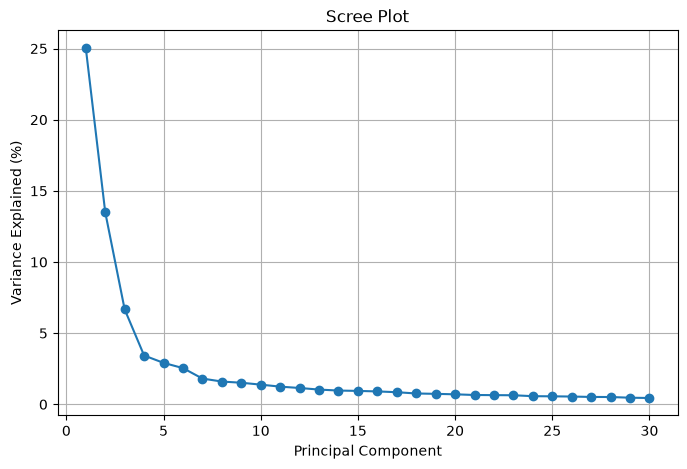

In [12]:
var_exp = (s_train**2) / np.sum(s_train**2)

# scree plot
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, 31), var_exp[:30]*100, marker='o')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot')
plt.grid(True)

plt.show()

C:\Users\Nitro\AppData\Local\Temp\ipykernel_11172\407257008.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


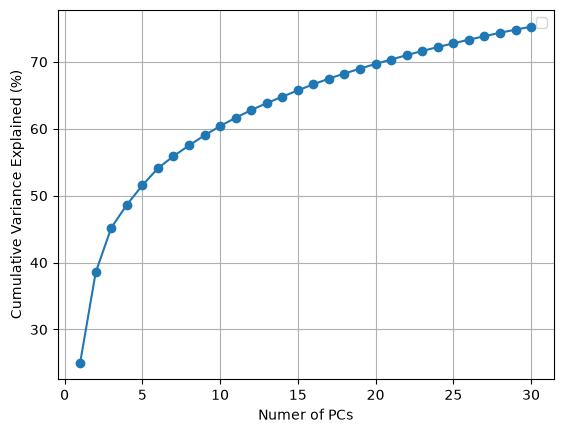

In [13]:
cum_var = np.cumsum(var_exp)

# cumulative variance plot
plt.Figure(figsize=(8, 5))
plt.plot(np.arange(1, 31), cum_var[:30]*100, marker='o')

#plt.axhline(y=80, color='r', linestyle='--', label='80% Variance Explained')

plt.xlabel('Numer of PCs')
plt.ylabel('Cumulative Variance Explained (%)')

plt.legend()
plt.grid(True)

plt.show()

### Test Dataset Preparation

In [14]:
# create SST anomalies
# use mean from train data
sst_test_anom = sst_test.groupby('time.month') - sst_train_mean

In [15]:
# convert to matrix for SVD
X_test = sst_test_anom.values.reshape(len(sst_test_anom.time), -1)
X_test.shape

(67, 259200)

In [16]:
# apply ocean mask
X_test = X_test[:, mask]

In [17]:
# apply latitude weighting
X_test_w = X_test * W

In [18]:
# get principal components
PCs_test = X_test_w @ VT_train.T

## Precipitation

### Target Variable Preparation

In [19]:
import geopandas as gpd

world = gpd.read_file('../data/ne_110m_admin_0_countries.zip')

world.head()

c:\Users\Nitro\miniconda3\envs\netcdf\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [20]:
brunei = world[world['NAME'].str.contains('Brunei', case=False, na=False)]

brunei

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
149,Admin-0 country,1,6,Brunei,BRN,0,2,Sovereign country,1,Brunei,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((115.45071 5.44773, 115.4057 4.95523,..."


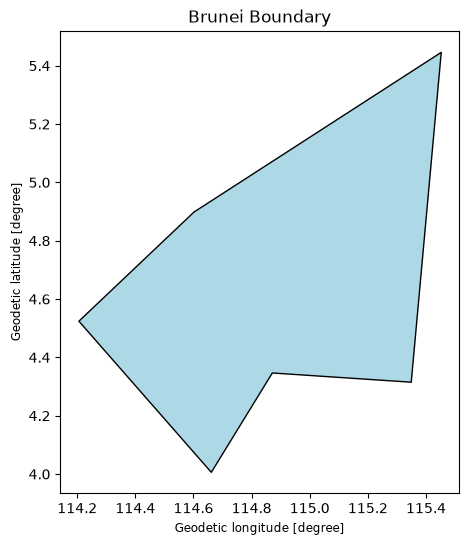

In [21]:
fig, ax = plt.subplots(figsize=(6,6))

brunei.plot(ax=ax, color='lightblue', edgecolor='black')

plt.title('Brunei Boundary')
plt.show()

In [24]:
import regionmask

mask = regionmask.mask_geopandas(brunei, pr.lon, pr.lat)

mask

<xarray.DataArray 'mask' (lat: 13, lon: 15)> Size: 2kB
array([[ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        149., 149., 149.,  nan],
       [ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan, 149.,
        149., 149., 149.,  nan],
       [ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan, 149., 149., 149.,
        149., 149., 149.,  nan],
       [ nan,  nan,  nan,  nan,  nan,  nan,  nan, 149., 149., 149., 149.,
        149., 149., 149.,  nan],
       [ nan,  nan,  nan,  nan,  nan, 149., 149., 149., 149., 149., 149.,
        149., 149., 149.,  nan],
       [ nan,  nan,  nan,  nan, 149., 149., 149., 149., 149., 149., 149.,
        149., 149., 149.,  nan],
       [ nan,  nan,  nan, 149., 149., 149., 149., 149., 149., 149., 149.,
        149., 149., 149.,  nan],
       [ nan,  nan, 149., 149., 149., 149., 149., 149., 149., 149., 149.,
        149., 149., 149.,  nan],
       [ nan,  nan,  nan, 149., 149., 149., 149., 149., 149., 149., 149.,
        149., 149., 149.,  nan],
       [ nan,  nan,  nan,  nan, 149., 149., 149., 149., 149., 149., 149.,
        149., 149., 149.,  nan],
       [ nan,  nan,  nan,  nan, 149., 149., 149., 149.,  nan,  nan,  nan,
         nan,  nan,  nan,  nan],
       [ nan,  nan,  nan,  nan,  nan, 149., 149.,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan],
       [ nan,  nan,  nan,  nan,  nan,  nan, 149.,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan]])
Coordinates:
  * lat      (lat) float32 52B 5.25 5.15 5.05 4.95 4.85 ... 4.35 4.25 4.15 4.05
  * lon      (lon) float32 60B 114.1 114.2 114.3 114.4 ... 115.3 115.4 115.4
Attributes:
    standard_name:  region

In [25]:
brunei_mask = ~mask.isnull()

n_cells = int(brunei_mask.sum())
print("Brunei Mask Cells:", n_cells)

Brunei Mask Cells: 90


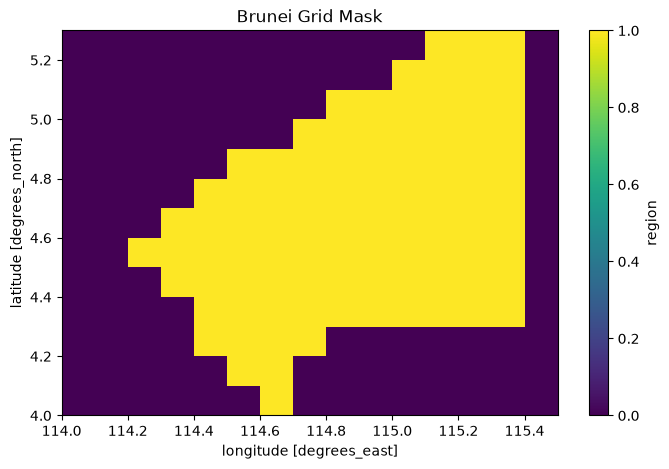

In [26]:
plt.figure(figsize=(8,5))

brunei_mask.plot()

plt.title('Brunei Grid Mask')
plt.show()

In [27]:
pr_masked = pr.where(brunei_mask)

pr_masked

<xarray.DataArray 'precipitation' (time: 16802, lat: 13, lon: 15)> Size: 13MB
array([[[       nan,        nan,        nan, ...,  0.0625   ,
          0.0625   ,        nan],
        [       nan,        nan,        nan, ...,  0.0625   ,
          0.0625   ,        nan],
        [       nan,        nan,        nan, ...,  0.1875   ,
          0.1875   ,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,  0.       ,
          0.       ,        nan],
        [       nan,        nan,        nan, ...,  0.       ,
          0.       ,        nan],
        [       nan,        nan,        nan, ...,  0.0625   ,
          0.125    ,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ..., 10.59375  ,
          7.4765625,        nan],
        [       nan,        nan,        nan, ..., 16.       ,
         14.546875 ,        nan],
        [       nan,        nan,        nan, ..., 18.820312 ,
         20.796875 ,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(16802, 13, 15), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1980-01-01 1980-01-02 ... 2025-12-31
  * lat      (lat) float32 52B 5.25 5.15 5.05 4.95 4.85 ... 4.35 4.25 4.15 4.05
  * lon      (lon) float32 60B 114.1 114.2 114.3 114.4 ... 115.3 115.4 115.4
Attributes:
    units:    mm d-1

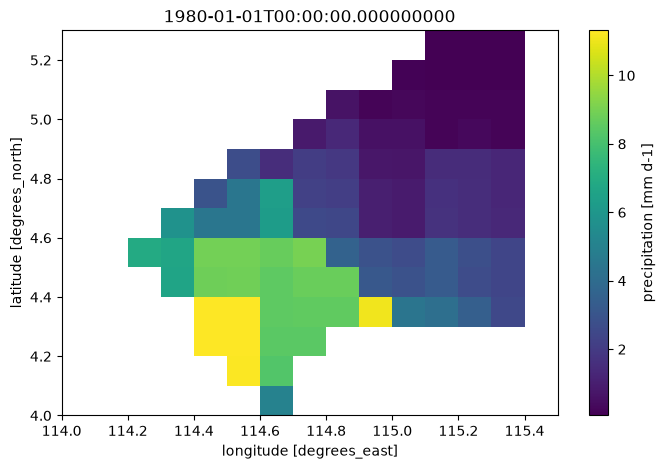

In [28]:
pr_masked.isel(time=0).plot(figsize=(8,5))

plt.title(str(pr.time.values[0]))
plt.show()

In [30]:
wet_days = pr_masked.where(pr_masked > 0.1)

In [45]:
p90_monthly = wet_days.groupby('time.month').quantile(0.9, dim='time', skipna=True)

c:\Users\Nitro\miniconda3\envs\netcdf\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\Nitro\miniconda3\envs\netcdf\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\Nitro\miniconda3\envs\netcdf\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\Nitro\miniconda3\envs\netcdf\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\Nitro\miniconda3\envs\netcdf\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\Nitro\miniconda3\envs\netcdf\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
c:\Users\Nitro\miniconda3\envs\net

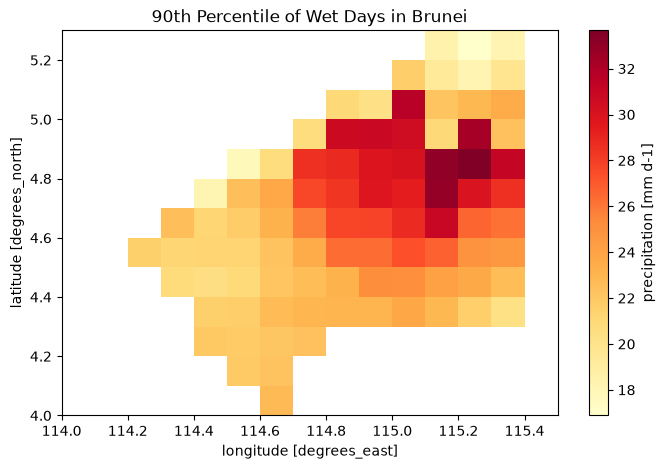

In [81]:
p90_monthly[5].plot(figsize=(8,5), cmap='YlOrRd')

plt.title('90th Percentile of Wet Days in Brunei')
plt.show()

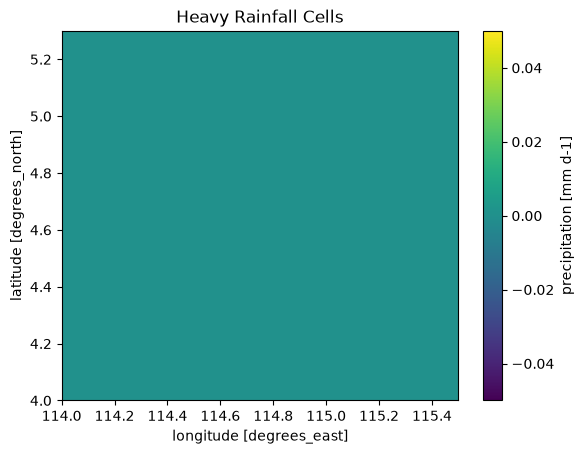

In [82]:
heavy_cells = pr_masked.groupby('time.month') > p90_monthly

heavy_cells.isel(time=25).plot()

plt.title('Heavy Rainfall Cells')
plt.show()

In [83]:
n_heavy = heavy_cells.sum(dim=['lat', 'lon'])

n_total = int(brunei_mask.sum())
n_total

90

In [84]:
daily_fraction = n_heavy / n_total
daily_fraction

<xarray.DataArray 'precipitation' (time: 16802)> Size: 134kB
array([0.        , 0.        , 0.        , ..., 0.35555556, 0.        ,
       0.        ], shape=(16802,))
Coordinates:
  * time      (time) datetime64[ns] 134kB 1980-01-01 1980-01-02 ... 2025-12-31
    quantile  (time) float64 134kB 0.9 0.9 0.9 0.9 0.9 ... 0.9 0.9 0.9 0.9 0.9
    month     (time) int64 134kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12
Attributes:
    units:    mm d-1

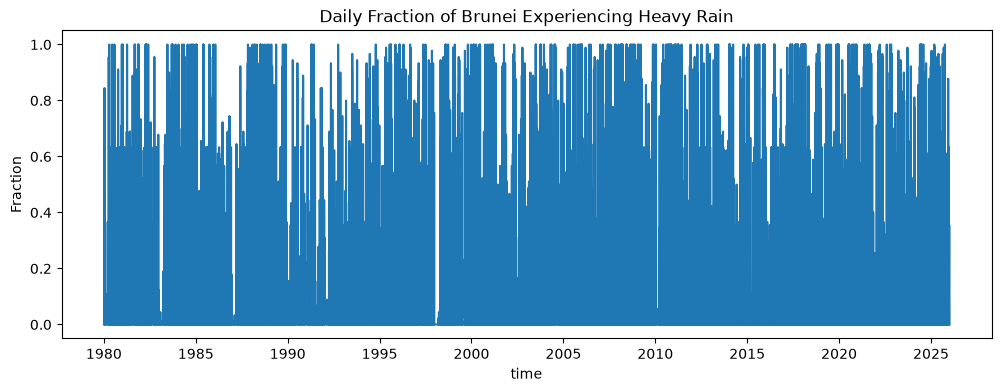

In [85]:
daily_fraction.plot(figsize=(12,4))

plt.ylabel('Fraction')
plt.title('Daily Fraction of Brunei Experiencing Heavy Rain')
plt.show()

In [86]:
heavy_day = daily_fraction >= 0.2
heavy_day = heavy_day.astype(int)
heavy_day

<xarray.DataArray 'precipitation' (time: 16802)> Size: 134kB
array([0, 0, 0, ..., 1, 0, 0], shape=(16802,))
Coordinates:
  * time      (time) datetime64[ns] 134kB 1980-01-01 1980-01-02 ... 2025-12-31
    quantile  (time) float64 134kB 0.9 0.9 0.9 0.9 0.9 ... 0.9 0.9 0.9 0.9 0.9
    month     (time) int64 134kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12
Attributes:
    units:    mm d-1

In [87]:
monthly_heavy_days = heavy_day.resample(time='MS').sum()
monthly_heavy_days

<xarray.DataArray 'precipitation' (time: 552)> Size: 4kB
array([ 6,  0,  1,  3,  4,  5,  6,  8,  2,  5,  7, 13, 14,  3,  2,  6,  9,
        3,  6,  0, 10,  4,  6,  4,  3,  2,  4, 10,  7,  3,  2,  1,  3,  3,
        3,  2,  0,  0,  0,  4,  6,  7,  5,  5,  7,  5,  2,  4,  7,  8,  2,
        4,  4,  3,  4,  1,  6, 10,  2,  5,  4,  3,  2,  7,  4,  3,  2,  4,
        2,  8,  4,  6,  5,  4,  5,  4,  1,  5,  5,  1,  3,  8,  6,  1,  0,
        0,  3,  1,  6, 10,  2,  8,  3,  4,  7,  6,  3,  5,  2,  2,  4,  5,
        6,  7,  8,  1,  6,  5,  0,  9,  4,  4,  1,  1,  1,  2,  3,  1,  3,
        1,  0,  1,  5,  4,  4,  2,  5,  0,  8,  2,  4,  0,  3,  2,  3,  3,
        8,  5,  0,  0,  5,  5,  6,  6,  0,  0,  1,  2,  7,  8,  5,  2,  7,
        8,  3,  5,  0,  2,  2,  2, 10,  2,  5,  2,  6,  9,  5,  6,  1,  3,
        8,  6,  3,  3,  3,  7,  4,  4,  4,  5,  1,  3,  5,  2,  8,  3,  5,
        8,  4,  1,  3,  7,  7,  5,  3,  5,  5,  6,  5,  6,  3,  7,  2,  5,
        3,  7,  1,  1,  8,  3,  6,  4,  2,  3,  7,  1,  0,  0,  0,  2,  3,
        4,  7,  6,  5,  6,  7,  7,  6,  7,  9,  8,  9,  2,  0,  2,  1, 10,
        2,  5,  1, 10,  8,  6,  1,  9,  0,  5,  8,  4,  6,  4,  9,  3, 10,
        4,  1,  3,  1,  3,  4, 10,  2,  3,  2,  2,  1,  8,  5,  1,  0,  4,
        4,  4,  4,  0,  5,  4,  6,  7,  6,  8,  5,  5,  2, 12,  3,  8,  2,
        2,  6,  5,  6,  3,  6,  1,  7,  0,  1,  3,  5,  0,  8,  2,  3,  8,
        5,  8,  4,  4,  8,  6,  7,  3,  6, 10,  7,  7,  5,  8,  6,  2,  5,
        6,  9,  4,  4,  4,  6, 10,  6,  3,  5,  4,  4,  1,  4, 10, 10,  6,
        3,  6,  6,  8,  5, 10,  6,  7, 17,  6,  3,  4,  2,  2,  2,  6,  4,
        7,  5,  4,  4,  0,  2,  4,  6,  3,  8,  8, 10,  4,  9,  5, 10,  9,
        9,  4,  2,  6,  2,  6,  6,  1,  4,  2,  5,  7,  6,  8,  2,  3,  7,
        6,  4,  5, 10,  5,  2,  4,  5,  5,  7,  3,  2,  4,  7,  1,  6,  8,
       13,  4,  6,  1,  4,  1,  1,  5,  2,  3,  6,  7, 10,  5,  2,  2,  2,
        6,  4,  4,  2,  1,  5,  7,  2,  2,  1,  3,  7,  5,  5,  1,  3,  5,
        5,  2,  3,  8,  4,  5,  6,  7,  2,  8,  3,  8,  4, 10,  9,  8,  5,
        8,  9,  4,  2,  2,  5,  5,  3,  6,  5,  1,  2,  6,  2,  6,  7,  1,
        2,  4,  4,  7,  2,  2,  5,  5,  5,  5, 12,  5,  6,  5,  8,  4,  7,
        6,  5,  3,  6,  4,  5, 14,  8,  4,  3,  2,  4,  9, 13,  6,  3,  3,
        3,  7,  3,  9,  4,  2,  4,  4, 12,  2,  3,  0,  6,  1,  8,  0,  4,
        3,  2,  3,  1,  4,  7,  8,  5,  9,  2,  4,  3,  7,  8,  8, 12,  6,
        4,  2,  0,  5,  7,  6,  3,  6])
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2025-12-01
Attributes:
    units:    mm d-1

In [88]:
heavy_df = monthly_heavy_days.to_dataframe(name='heavy_days').reset_index()
heavy_df.head()

,time,heavy_days
0,1980-01-01,6
1,1980-02-01,0
2,1980-03-01,1
3,1980-04-01,3
4,1980-05-01,4


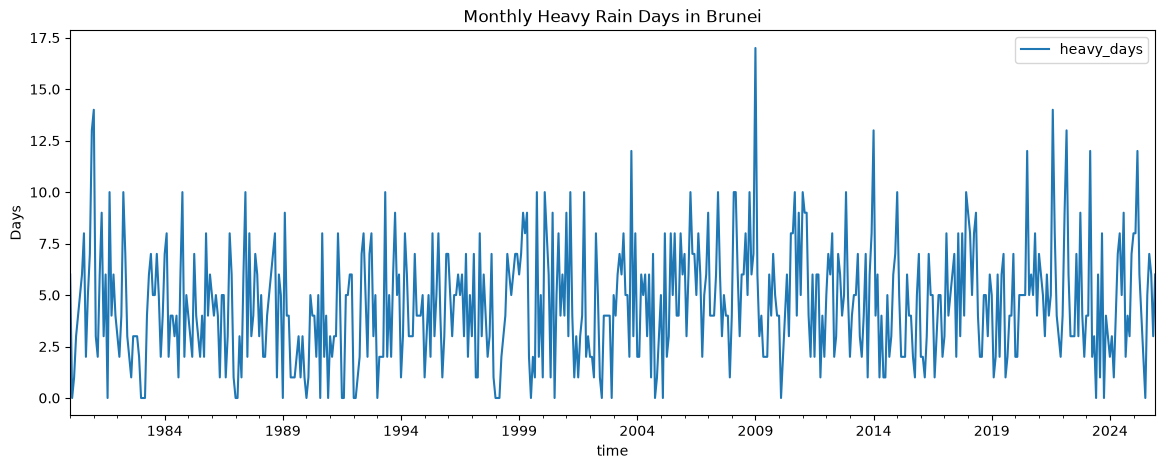

In [89]:
heavy_df.plot(x='time', y='heavy_days', figsize=(14,5))

plt.title('Monthly Heavy Rain Days in Brunei')
plt.ylabel('Days')
plt.show()

### Merge PCs and Target Variable

In [92]:
# introduce 1 month lead to target variable
heavy_df['heavy_days_lead'] = heavy_df['heavy_days'].shift(-1)
heavy_df.head()

,time,heavy_days,heavy_days_lead
0,1980-01-01,6,0.0
1,1980-02-01,0,1.0
2,1980-03-01,1,3.0
3,1980-04-01,3,4.0
4,1980-05-01,4,5.0


In [96]:
import pandas as pd

# merge PCs and heavy rain days

# TODO: convert PCs to DataFrame, select dominant PCs, merge with heavy_df, and save to CSV for modeling

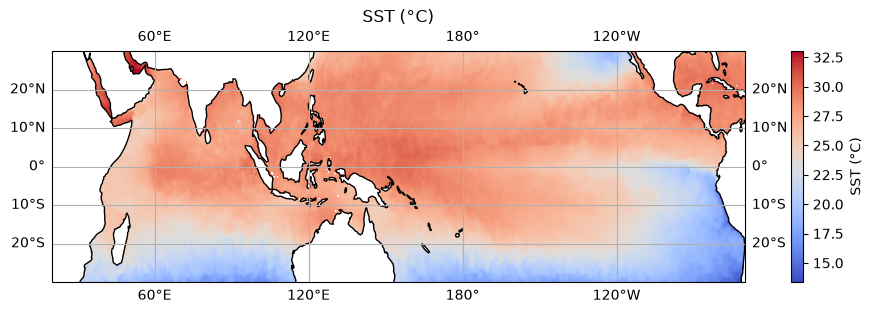

In [97]:
fig = plt.figure(figsize=(12, 3))

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

sst.isel(time=0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    cbar_kwargs={'label': 'SST (°C)'}
)

ax.coastlines()
ax.gridlines(draw_labels=True)

ax.set_aspect(aspect=1.5)

plt.title('SST (°C)')
plt.show()

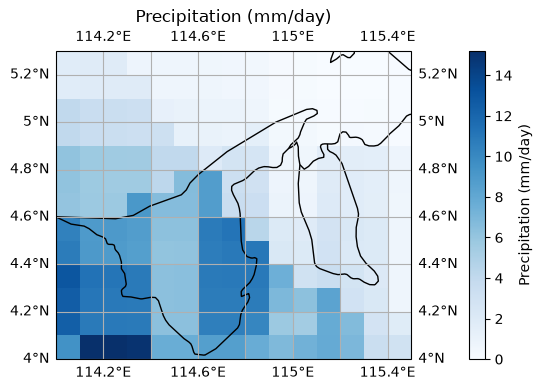

In [98]:
import cartopy.feature as cfeature

plt.figure(figsize=(15, 4))

ax = plt.axes(projection=ccrs.PlateCarree())

pr.isel(time=1).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    cbar_kwargs={'label': 'Precipitation (mm/day)'}
)

ax.add_feature(cfeature.BORDERS)
ax.coastlines()
ax.gridlines(draw_labels=True)

plt.title('Precipitation (mm/day)')
plt.show()

